In [1]:
import numpy as np
import glob
import healpy as hp
import time

from vorothreshold import voronoi_threshold 
from vorothreshold.read_funcs import read_voronoi_vide, read_adjfile
from vorothreshold.utilities import from_XYZ_to_rRAdec, from_rRAdec_to_XYZ, ComovingDistanceOverh, RedshiftFromComovingDistanceOverh, StrHminSec
from vorothreshold.masks import borders_mask_bruteforce, dist_limit_mask, borders_mask
from vorothreshold.overlaps import overlapping_fraction, select_overlaps, compute_max_dist2, \
    order_ids_tracers_selected_in_voxels, order_coord_tracers_in_voxels_ids_rev_copy, \
        nearest_cell_core, nearest_cell_loop, center_in_void_core, center_in_void_loop, center_in_void, center_in_void_given_voro,closest_voro

import matplotlib.pyplot as plt

In [2]:
vide_path='data/lightcone/examples/example_observation/sample_example_observation/'
OmegaM = 0.3
sample_name = 'example_observation'
ids_voro, VoroVol, VoroXYZ, RA, Dec, redshift = read_voronoi_vide(vide_path,sample_name)

In [3]:
adjfile = glob.glob(vide_path+'/adj_*')[0] #vide_path + '/adj_' + vide_out_name + '.dat'
neighbor_ptr, neighbor_ids = read_adjfile(adjfile)

# recover vide_out_name
vide_out_name = adjfile.split('adj_')[1].split('.dat')[0]
#if ID_core is None:
# Load ids of cells belonging to minima
ID_core = np.loadtxt(vide_path+'/untrimmed_voidDesc_all_'+vide_out_name+'.out', comments='#', skiprows=2)[:,2].astype(np.int_)
# Load Voronoi cells volume, ids and tracers position
ids_voro, VoroVol, VoroXYZ, RAvoro, DECvoro, redshift_voro = read_voronoi_vide(vide_path,vide_out_name)

#OmegaM = load_pickle_safe(vide_path+'/sample_info.dat')['omegaM']


dist_z = ComovingDistanceOverh(OmegaM,-1.,0.)

dist_voro = dist_z.get_dist(redshift_voro)
VoroXYZ[:,:] = np.array(from_rRAdec_to_XYZ(dist_voro,RAvoro,DECvoro)).T

max_num_part = int(5 * np.max(np.loadtxt(vide_path+'/untrimmed_centers_all_'+vide_out_name+'.out', comments="#")[:,9]))


hist_z, z_bins = np.histogram(redshift,bins=31)


mask_gal_file = vide_path + 'mask_map.fits'
mask_pix = hp.read_map(mask_gal_file)
sky_frac = np.sum(mask_pix)/mask_pix.shape[0]

comov_bins = dist_z.get_dist(z_bins)
comov3 = dist_z.get_dist(z_bins)**3
shell_vol = 4*np.pi/3.*sky_frac*(comov3[1:] - comov3[:-1])
z_mean = 0.5 * (z_bins[1:] + z_bins[:-1])
dist_mean = dist_z.get_dist(z_mean)
mean_dens = np.mean((hist_z/shell_vol)[(dist_mean>=75) & (dist_mean<=400)])

tracer_dens = np.full(redshift.shape[0],mean_dens)


In [4]:
threshold = [0.3]
void_selected, ID_voro_dict, Xcm, Vol_interp, Ncells_in_void, ell_eigenvalues, ell_eigenvectors = voronoi_threshold(
    threshold,ID_core,neighbor_ptr,neighbor_ids,VoroXYZ,VoroVol,tracer_dens,Lbox=-1,nthreads=-1,verbose=True,max_num_part=max_num_part)
        


    voronoi_threshold started. 

    nthreads set to 32

    max_num_part set to 3685

    computation started
    done, 0 h 0 min 10.61359691619873 sec. 



In [5]:

i_min = np.argmin(dist_voro)
i_max = np.argmax(dist_voro)
comov_range_base = [250.,400.]

comov_range = np.array(comov_range_base)
if len(comov_range.shape) == 1:
    comov_range = np.empty((len(threshold),2))
    comov_range[:,0] = min(comov_range_base)
    comov_range[:,1] = max(comov_range_base)
elif comov_range.shape[0] < len(threshold):
    comov_range = np.empty((len(threshold),2))
    comov_range[:,0] = min(comov_range_base)
    comov_range[:,1] = max(comov_range_base)
print(comov_range)

[[250. 400.]]


In [6]:
nside = hp.get_nside(mask_pix)
healpix_mask = dict()
ids_selected = dict()
for ith in range(len(threshold)):
    trs_mask = (dist_voro >= comov_range[ith,0]) & (dist_voro <= comov_range[ith,1])
    ang_paddig_rad = 2. * np.max(tracer_dens[trs_mask]**(-1./3.) / dist_voro[trs_mask])
    npadding_ang = int((ang_paddig_rad + hp.nside2resol(nside)) / hp.nside2resol(nside))
    mask_ids, mask_voro, healpix_mask[ith] = borders_mask(mask_pix,RAvoro,DECvoro,ID_voro_dict,Ncells_in_void[:,ith],npadding_ang)
    ids_selected[ith] = dist_limit_mask(mask_ids,Xcm[:,ith,:],comov_range[ith,0],comov_range[ith,1],
                            VoroXYZ,Ncells_in_void[:,ith],ID_voro_dict) 
    print(ang_paddig_rad,npadding_ang,ids_selected[ith].shape)
    print(Xcm.shape[0],'-->',ids_selected[ith].shape[0],ids_selected[ith])
                


0.059876929758343425 8 (136,)
214 --> 136 [  0   4   7   8   9  11  14  15  16  18  19  21  22  24  30  32  33  34
  37  38  41  42  43  44  45  48  49  52  54  55  57  58  59  60  61  62
  63  64  65  66  67  68  69  70  71  72  76  79  80  84  85  86  89  91
  92  97  98  99 102 103 104 106 108 109 110 112 113 118 120 123 124 126
 127 128 129 130 131 132 134 135 136 138 140 141 142 146 147 149 150 151
 154 155 157 158 159 160 161 163 164 165 166 167 168 169 170 171 172 173
 174 175 176 177 178 181 182 185 186 187 188 190 191 192 193 195 196 198
 199 200 202 203 204 207 209 211 212 213]


In [7]:
ids_ovlp_frac = dict()
Vol_ovlp_frac = dict()
num_ovlps_frac = dict()
sort_by_vol_frac = dict()
id_out_frac = dict()

In [8]:
frac_ovlp = 0.3

id_out_frac[ith] = dict()
ids_ovlp_frac[ith], Vol_ovlp, Vol_ovlp_frac[ith], num_ovlps_frac[ith] = overlapping_fraction(
    Xcm[:,ith,:], Vol_interp[:,ith], Ncells_in_void[:,ith], VoroXYZ, VoroVol, ID_voro_dict,
    Lbox=-1,lightcone=True,id_selected=ids_selected[ith],nthreads=-1,verbose=True)
sort_by_vol_frac[ith] = np.argsort(Vol_interp[ids_selected[ith],ith])[::-1].astype(dtype=np.int_,order='C')

id_out_frac[ith][frac_ovlp] = select_overlaps(frac_ovlp,ids_selected[ith],sort_by_vol_frac[ith], ids_ovlp_frac[ith], Vol_ovlp_frac[ith], num_ovlps_frac[ith])


overlapping_fraction started.

    nthreads set to 32

    R_max computed. Max val = 44.66014755275007

    Lbox not passed, using xyz_vds as reference:
    min(xyz_vds) = -292.17148326489206 -370.03584395371087 24.49048957489266
    max(xyz_vds) = 276.63418947328694 -102.15536361583469 320.68229381827257
    Lbox = 568.805672738179

    ngrid not passed. Set to optimal value: 13

    order_ids_tracers_selected_in_voxels started
    done, 0 h 0 min 0.4914052486419678 sec.

    computation started (periodic-boundaries condition off)
    done, 0 h 0 min 3.1494362354278564 sec. 



In [9]:
print(id_out_frac[ith][frac_ovlp].shape,id_out_frac[ith][frac_ovlp])

(122,) [  7  66  70   0  28  62  77  41  48   8  45 133  18 108  86  38  47  51
 118  13 102 124  88  10  42  30 109   9  65  21  74  39  82  33  72  36
  26 115  23  25  92  71  87 120 113 129 110  56  32 125 126  93  49  96
  54  94  24  79 121  73  27 134 114  46  20  90  37  64  75  59  19 117
  34   2   4  67  89 127 112  95  29  69 101  55  11 135  81  16 104 119
   1  63  53  43 122  80   3 132  12  60  14  15 123   5  17  52  84  61
 111  22 105 100 130  76   6  58  91  50 116  35  68  31]


In [10]:
id_ovlp_out = ids_selected[ith][id_out_frac[ith][frac_ovlp]]
print(id_ovlp_out.shape,id_ovlp_out)

(122,) [ 15 113 124   0  54 108 132  68  80  16  72 211  37 174 147  65  79  86
 188  24 168 196 150  19  69  57 175  18 112  42 129  66 140  60 127  63
  49 185  44  48 157 126 149 191 181 203 176  98  59 198 199 158  84 161
  92 159  45 135 192 128  52 212 182  76  41 154  64 110 130 103  38 187
  61   7   9 118 151 200 178 160  55 123 167  97  21 213 138  33 170 190
   4 109  91  70 193 136   8 209  22 104  30  32 195  11  34  89 142 106
 177  43 171 166 204 131  14 102 155  85 186  62 120  58]


start checking center in void

In [11]:
Ncells = np.copy(Ncells_in_void[:,ith])
id_selected = np.arange(Ncells.shape[0])[Ncells > 1.]
xyz_vds = np.copy(Xcm[:,ith,:])
max_dist_vds = compute_max_dist2(Ncells,xyz_vds,VoroXYZ,id_selected,ID_voro_dict)**0.5
print('R_max:',np.max(max_dist_vds),max_dist_vds.shape)


offset = np.min(VoroXYZ,axis=0)
max_values = np.max(VoroXYZ,axis=0)
Lbox = np.max(max_values - offset)

offset -= Lbox*1e-4
max_values += Lbox*1e-4
Lbox = np.max(max_values - offset)
ngrid = max(int(round(Lbox / 20.)),4)


print("    min(xyz_vds) =",*offset,flush=True)
print("    max(xyz_vds) =",*max_values,flush=True)
print("    Lbox =",Lbox,flush=True)
print("    ngrid:",ngrid,flush=True)


voxel_side = Lbox / ngrid

print('\n    order_ids_tracers_selected_in_voxels started',flush=True)
#print(VoroXYZ.shape,VoroXYZ[:10,:])

t0 = time.time()

#IDs_vds_ordered, voxel_ptr = order_ids_tracers_in_voxels(xyz_vds, ngrid, Lbox)
xyz_trs_out, ids_reverse, ind_vox = order_coord_tracers_in_voxels_ids_rev_copy(VoroXYZ - offset, ngrid, Lbox)

dt = time.time() - t0
print("    done,",StrHminSec(dt),flush=True)

#print(np.min(xyz_trs_out),np.max(xyz_trs_out),xyz_trs_out[:10,:])

R_max: 99.34885906394673 (214,)
    min(xyz_vds) = -404.89752 -433.31003 -84.366234
    max(xyz_vds) = 379.357 432.73975 402.80176
    Lbox = 866.0498
    ngrid: 43

    order_ids_tracers_selected_in_voxels started
    done, 0 h 0 min 1.2290899753570557 sec.


In [12]:
print(ids_reverse)

[91561 96469  1078 ... 21302 21303 21305]


In [13]:
id_loop = 87
R_max = np.max(max_dist_vds)
Rvds = Vol_interp[:,ith]**(1/3)*3/(4*np.pi)

max_iterations = 3
t0 = time.time()
ids_closest = nearest_cell_loop(
    id_selected, xyz_vds-offset, xyz_trs_out, ids_reverse, ind_vox, ngrid, voxel_side, max_iterations)
print(time.time()-t0)

5.082156419754028


In [14]:
dist_closest = np.sum((xyz_vds[id_selected,:] - VoroXYZ[ids_closest,:])**2,axis=1)**0.5
dist_test = np.zeros(id_selected.shape[0])

t0 = time.time()
for ii in range(id_selected.shape[0]):
    dist_test[ii] = np.min(np.sum((xyz_vds[ii,:] - VoroXYZ)**2,axis=1)**0.5)
print(time.time()-t0)

print(np.max(np.abs(dist_closest - dist_test)))

0.4276766777038574
0.0


In [15]:
ngrid = max(int(round(Lbox / np.max(max_dist_vds) )),4)

voxel_side = Lbox / ngrid

print('ngrid:',ngrid)
print('voxel_side:',voxel_side)
IDs_vds_ordered, id_sorted, voxel_ptr = order_ids_tracers_selected_in_voxels(xyz_vds - offset,id_selected, ngrid, Lbox)

ngrid: 9
voxel_side: 96.22775


In [16]:
ids_closest_ordered = ids_closest[id_sorted]

In [17]:
IDS_voids, id_sorted, XYZ_voids, VolVoids, Ncells, ids_voro_center, max_dist_vds, Ids_voro_dict, ind_vox, ngrid, voxel_side = \
IDs_vds_ordered, id_sorted, xyz_vds - offset, Vol_interp[:,ith], Ncells, ids_closest, max_dist_vds, ID_voro_dict, voxel_ptr, ngrid, voxel_side


id_loop = 84
id_loop = np.argmax(Rvds[IDS_voids])

In [18]:

id_loop = 195
id_loop = np.arange(IDS_voids.shape[0])[IDS_voids == 87][0]

id_void = IDS_voids[id_loop]
id_voro = ids_voro_center[id_void]

print('id_loop:',id_loop,'id_void:',id_void,'id_voro:',id_voro)
XYZ_ref = XYZ_voids[id_void,:]

dist_max = max_dist_vds[id_void] + R_max
dist2_max = dist_max * dist_max


print(id_loop,Rvds[IDS_voids[id_loop]],np.max(Rvds),dist_max)
# initialize arrays:
max_num_vox_for_sphere = int(4 * 3.1416 / 3 * (int((dist_max-1) / voxel_side) + 1 + 0.5 * np.sqrt(3))**3) + 1
max_num_vox_for_sphere = max(max_num_vox_for_sphere, 27)


half_n_vox_side = int((dist_max-1) / voxel_side) + 1


ijk_in_sphere = np.empty((max_num_vox_for_sphere,3),dtype=np.int64)
vox_dist_from_xyz = np.empty(3,dtype=np.float64)
xyz_vox_unit = XYZ_ref / voxel_side
ijk_vox_void_center = xyz_vox_unit.astype(np.int64)

i_in = max(int(xyz_vox_unit[0] - half_n_vox_side),0)
i_out = min(int(xyz_vox_unit[0] + half_n_vox_side + 1),ngrid)
j_in = max(int(xyz_vox_unit[1] - half_n_vox_side),0)
j_out = min(int(xyz_vox_unit[1] + half_n_vox_side + 1),ngrid)
k_in = max(int(xyz_vox_unit[2] - half_n_vox_side),0)
k_out = min(int(xyz_vox_unit[2] + half_n_vox_side + 1),ngrid)


id_loop: 84 id_void: 87 id_voro: 130756
84 20.765188359354863 20.765188359354863 198.69771812789338


max_num_tracers: 169
progr_sphere: 0
dist2_min: 6.462348535570529e-27
dist2_max: 39480.78318923177
-1 -1.0


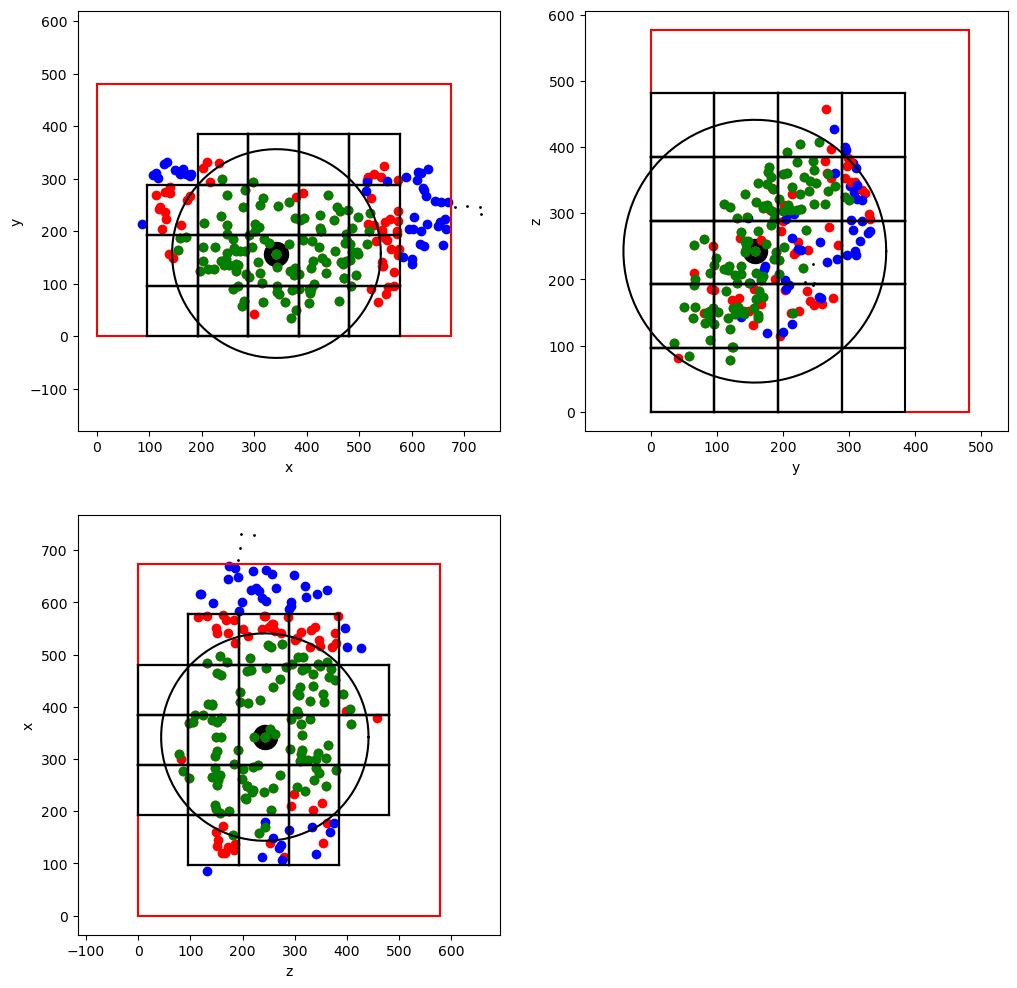

In [19]:

progr = 0
dist_max = max_dist_vds[id_void] + R_max
dist2_max = dist_max * dist_max
r2_vox_unit = dist2_max / (voxel_side * voxel_side)
max_num_tracers = 0


fig = plt.figure(figsize=(12,12))
ax = dict()
for xx in range(3):
    ax[xx] = plt.subplot2grid((2,2), (int(xx/2),xx%2), rowspan=1, colspan=1)
    ax[xx].scatter(XYZ_ref[xx],XYZ_ref[(xx+1)%3],c='k',s=300)
    theta = np.linspace(0,2*np.pi,100)
    ax[xx].scatter(XYZ_voids[:,xx],XYZ_voids[:,(xx+1)%3],c='k',s=1)
    ax[xx].plot(XYZ_ref[xx]+dist_max*np.cos(theta),XYZ_ref[(xx+1)%3]+dist_max*np.sin(theta),c='k')
    ax[xx].set_xlabel(['x','y','z'][xx])
    ax[xx].set_ylabel(['x','y','z'][(xx+1)%3])

    i1_in = [i_in,j_in,k_in][xx]
    i2_in = [i_in,j_in,k_in][(xx+1)%3]
    i1_out = [i_out,j_out,k_out][xx]
    i2_out = [i_out,j_out,k_out][(xx+1)%3]

    ax[xx].plot([i1_in*voxel_side,i1_out*voxel_side],
                [i2_in*voxel_side,i2_in*voxel_side],c='r')
    ax[xx].plot([i1_in*voxel_side,(i1_out)*voxel_side],
                [(i2_out)*voxel_side,(i2_out)*voxel_side],c='r')
    ax[xx].plot([i1_in*voxel_side,i1_in*voxel_side],
                [i2_in*voxel_side,(i2_out)*voxel_side],c='r')
    ax[xx].plot([(i1_out)*voxel_side,(i1_out)*voxel_side],
                [i2_in*voxel_side,(i2_out)*voxel_side],c='r')

for i in range(i_in,i_out):
    for j in range(j_in,j_out):
        for k in range(k_in,k_out):
            ijk_in_sphere[progr,0] = i
            ijk_in_sphere[progr,1] = j
            ijk_in_sphere[progr,2] = k
            #// Compute the distance between the center and the closest vertex of voxel i,j,k:
            #// if i < xyz_vox_unit[0] (voxels at left) compare the distance wrt i+1, 
            #// i.e. right vertex of voxel instead of the left one
            vox_dist_from_xyz[0] = i + int(i < xyz_vox_unit[0]) - xyz_vox_unit[0]
            vox_dist_from_xyz[1] = j + int(j < xyz_vox_unit[1]) - xyz_vox_unit[1]
            vox_dist_from_xyz[2] = k + int(k < xyz_vox_unit[2]) - xyz_vox_unit[2]
            #// Compute the square of the distance. The boolean condition is to an exact computation 
            #// of the minimum distance between the center and the voxel:
            #// if , e.g. i == ijk_vox_void_center[0] the minimum distance occurs at the side, not at vertex,
            #// i.e. the minimu radius is has the same x coord of the center, therefore the x projection
            #// of the radius is 0, i.e. (i != ijk_vox_void_center[0])=0.
            #// This algorithm automatically select the voxel to which the center belong, 
            #// independently on the radius and voxel size
            vox_dist_from_xyz[0] *= vox_dist_from_xyz[0] * int(i != ijk_vox_void_center[0])
            vox_dist_from_xyz[1] *= vox_dist_from_xyz[1] * int(j != ijk_vox_void_center[1])
            vox_dist_from_xyz[2] *= vox_dist_from_xyz[2] * int(k != ijk_vox_void_center[2])

            vox_in_sphere = (vox_dist_from_xyz[0] + vox_dist_from_xyz[1] + vox_dist_from_xyz[2]) < r2_vox_unit

            id_vox_tmp = i * ngrid * ngrid + j * ngrid + k
            max_num_tracers += (ind_vox[id_vox_tmp+1]-ind_vox[id_vox_tmp]) * int(vox_in_sphere)
            if vox_in_sphere:
                for xx in range(3): 
                    ax[xx].scatter(XYZ_voids[IDS_voids[ind_vox[id_vox_tmp]:ind_vox[id_vox_tmp+1]],xx],
                                   XYZ_voids[IDS_voids[ind_vox[id_vox_tmp]:ind_vox[id_vox_tmp+1]],(xx+1)%3],c='r')
                    ax[xx].plot([ijk_in_sphere[progr,xx]*voxel_side,(ijk_in_sphere[progr,xx]+1)*voxel_side],
                                [ijk_in_sphere[progr,(xx+1)%3]*voxel_side,ijk_in_sphere[progr,(xx+1)%3]*voxel_side],c='k')
                    ax[xx].plot([ijk_in_sphere[progr,xx]*voxel_side,(ijk_in_sphere[progr,xx]+1)*voxel_side],
                                [(ijk_in_sphere[progr,(xx+1)%3]+1)*voxel_side,(ijk_in_sphere[progr,(xx+1)%3]+1)*voxel_side],c='k')
                    ax[xx].plot([ijk_in_sphere[progr,xx]*voxel_side,ijk_in_sphere[progr,xx]*voxel_side],
                                [ijk_in_sphere[progr,(xx+1)%3]*voxel_side,(ijk_in_sphere[progr,(xx+1)%3]+1)*voxel_side],c='k')
                    ax[xx].plot([(ijk_in_sphere[progr,xx]+1)*voxel_side,(ijk_in_sphere[progr,xx]+1)*voxel_side],
                                [ijk_in_sphere[progr,(xx+1)%3]*voxel_side,(ijk_in_sphere[progr,(xx+1)%3]+1)*voxel_side],c='k')
            else:
                for xx in range(3): 
                    ax[xx].scatter(XYZ_voids[IDS_voids[ind_vox[id_vox_tmp]:ind_vox[id_vox_tmp+1]],xx],
                                   XYZ_voids[IDS_voids[ind_vox[id_vox_tmp]:ind_vox[id_vox_tmp+1]],(xx+1)%3],c='b')

            progr += int(vox_in_sphere)
print('max_num_tracers:',max_num_tracers)
   
progr_sphere = 0
max_num_tracers += 1

ids_to_expore = np.zeros(max_num_tracers,dtype=np.int64)
#// select voxels intersecting with the sphere centered in the void center

#dist2_max = dist2_max / 4 #(Rvds[id_void]*3)**2
dist2_min = dist2_max
id_trs_min = -1
for id_vox in range(progr):
    i_tmp = ijk_in_sphere[id_vox,0]
    j_tmp = ijk_in_sphere[id_vox,1]
    k_tmp = ijk_in_sphere[id_vox,2]
    id_vox_tmp = i_tmp * ngrid * ngrid + j_tmp * ngrid + k_tmp

    #print(id_vox,ijk_in_sphere[id_vox,:],id_vox_tmp)
    #if (i_tmp == 0) & (j_tmp == 2) & (k_tmp == 1):
    #    print(id_vox_tmp)
                        
    for id_ptr in range(ind_vox[id_vox_tmp],ind_vox[id_vox_tmp+1]):
        id_trs = IDS_voids[id_ptr]
        ids_to_expore[progr_sphere] = id_trs
        dist2 = np.sum(np.square(XYZ_voids[id_trs,:] - XYZ_ref))
        progr_sphere += int((dist2 <= dist2_max) & (VolVoids[id_trs] > VolVoids[id_void]) & (id_trs != id_void))

        if (dist2 <= dist2_max): #& (VolVoids[id_trs] > VolVoids[id_void]) & (id_trs != id_void):
            if (dist2 < dist2_min) & (id_trs != id_void):
                dist2_min = dist2
                id_trs_min = id_trs
            #if (VolVoids[id_trs] > VolVoids[id_void]) & (id_trs != id_void):
            if (VolVoids[id_trs] > VolVoids[id_void]) & (id_trs != id_void):
                for xx in range(3): 
                    ax[xx].scatter(XYZ_voids[id_trs,xx],XYZ_voids[id_trs,(xx+1)%3],c='m')
                print(id_trs,dist2**0.5,(VolVoids[id_void])**(1/3.)*3/(4*np.pi),(VolVoids[id_trs])**(1/3.)*3/(4*np.pi))
            else:
                for xx in range(3): 
                    ax[xx].scatter(XYZ_voids[id_trs,xx],XYZ_voids[id_trs,(xx+1)%3],c='g')
print('progr_sphere:',progr_sphere)
print('dist2_min:',dist2_min)
print('dist2_max:',dist2_max)

max_vol = -1.
id_overlap = -1
for id_trs in ids_to_expore[:progr_sphere]:
    Ncells_loop = int(Ncells[id_trs]) + int(round(Ncells[id_trs]%1))


    overlap = (id_voro in Ids_voro_dict[id_trs][:Ncells_loop]) #& (VolVoids[id_trs] > max_vol)

    if overlap:
        print(id_trs,overlap,max_vol)

    id_overlap = id_overlap * int(not overlap) + id_trs * int(overlap)
    max_vol = max_vol * int(not overlap) + VolVoids[id_trs] * int(overlap)

print(id_overlap,max_vol)

Rfac = 3.
for xx in range(3):
    ax[xx].axis('equal')
    #ax[xx].set_xlim(XYZ_ref[xx]-Rvds[id_void]*Rfac,XYZ_ref[xx]+Rvds[id_void]*Rfac)
    #ax[xx].set_ylim(XYZ_ref[(xx+1)%3]-Rvds[id_void]*Rfac,XYZ_ref[(xx+1)%3]+Rvds[id_void]*Rfac)
    #



In [20]:

#id_overlap=142
print("id_voro:",id_voro)
print(dist2_min**0.5,id_trs_min,id_void,id_overlap)

print(np.arange(IDS_voids.shape[0])[IDS_voids == id_overlap])

Ncells_ref = int(Ncells[id_void]) + int(round(Ncells[id_void]%1))
Ncells_min = int(Ncells[id_trs_min]) + int(round(Ncells[id_trs_min]%1))
Ncells_ovlp = int(Ncells[id_overlap]) + int(round(Ncells[id_overlap]%1))
print("XYZ_voids:",XYZ_voids[id_void,:],XYZ_voids[id_trs_min,:],XYZ_voids[id_overlap,:])
print("Ncells:",Ncells_ref,Ncells_min,Ncells_ovlp)
print("Rvds:",Rvds[id_void],Rvds[id_trs_min],Rvds[id_overlap])
print("Rvds==Rref:",Rvds[id_void]==Rvds[id_trs_min],Rvds[id_void]==Rvds[id_overlap])
print("id_voro:",id_voro,ids_closest[id_trs_min],ids_closest[id_overlap])#,ids_closest[id_loop],ids_closest[id_void])
print(VoroXYZ[id_voro,:]-offset-XYZ_voids[id_void,:],VoroXYZ[ids_closest[id_trs_min],:]-offset-XYZ_voids[id_trs_min,:])
try:
    print(np.sum((VoroXYZ[id_voro,:]-XYZ_voids[id_void,:]-offset)**2)**0.5,np.sum((VoroXYZ[ids_closest[id_trs_min],:]-offset-XYZ_voids[id_trs_min,:])**2)**0.5)
    print(id_voro in Ids_voro_dict[id_void][:Ncells_ref],id_voro in Ids_voro_dict[id_trs_min][:Ncells_min],id_voro in Ids_voro_dict[id_overlap][:Ncells_ovlp])
    print(VoroVol[id_voro])
except:
    pass

id_voro: 130756
8.038873388460929e-14 194 87 -1
[]
XYZ_voids: [342.09093857 157.48543308 242.58818254] [342.09093857 157.48543308 242.58818254] [284.51641441 118.95949619 220.00042365]
Ncells: 471 471 6
Rvds: 20.765188359354863 20.765188359354855 4.872661835811007
Rvds==Rref: False False
id_voro: 130756 130756 147928
[-1.06914902  3.36063625  2.2368907 ] [-1.06914902  3.36063625  2.2368907 ]
4.1762057270696005 4.176198710729396


Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


[140973 142913 140959 151962 143443 143663 143458 141685 151735 143341
 130777 131518 130205 130779 130785 151247 150985 152164 142965 132122
 129241 132360 152168 131061 132118 152161 143192 129237 132097 130782
 152167 141179 132640 129245 151955 129069 130261 143071 130262 134032
 134031 142753 143239 143044 129054 151231 142961 152372 141156 143526
 131508 143641 132095 131257 131035 129767 140066 143188 140063 143315
 129053 140753 143625 143768 150523 140937 147563 131246 143158 143760
 130756 138720 139614 130466 139815 140055 131245 147170 146319 149972
 150990 156687 143053 147929 150522 155949 149962 141162 151459 142765
 143449 160989 131341 143788 143509 156133 151950 143252 156308 151913
 153658 140072 143183 130259 140081 131038 141359 129481 126206 140968
 126281 127522 123336 141700 127499 127500 130770 150984 146762 149983
 151509 149981 140967 154187 156699 149982 153919 153663 130755 125816
 130179 141328 141325 131030 140057 143051 141335 139821 126670 131251
 12666

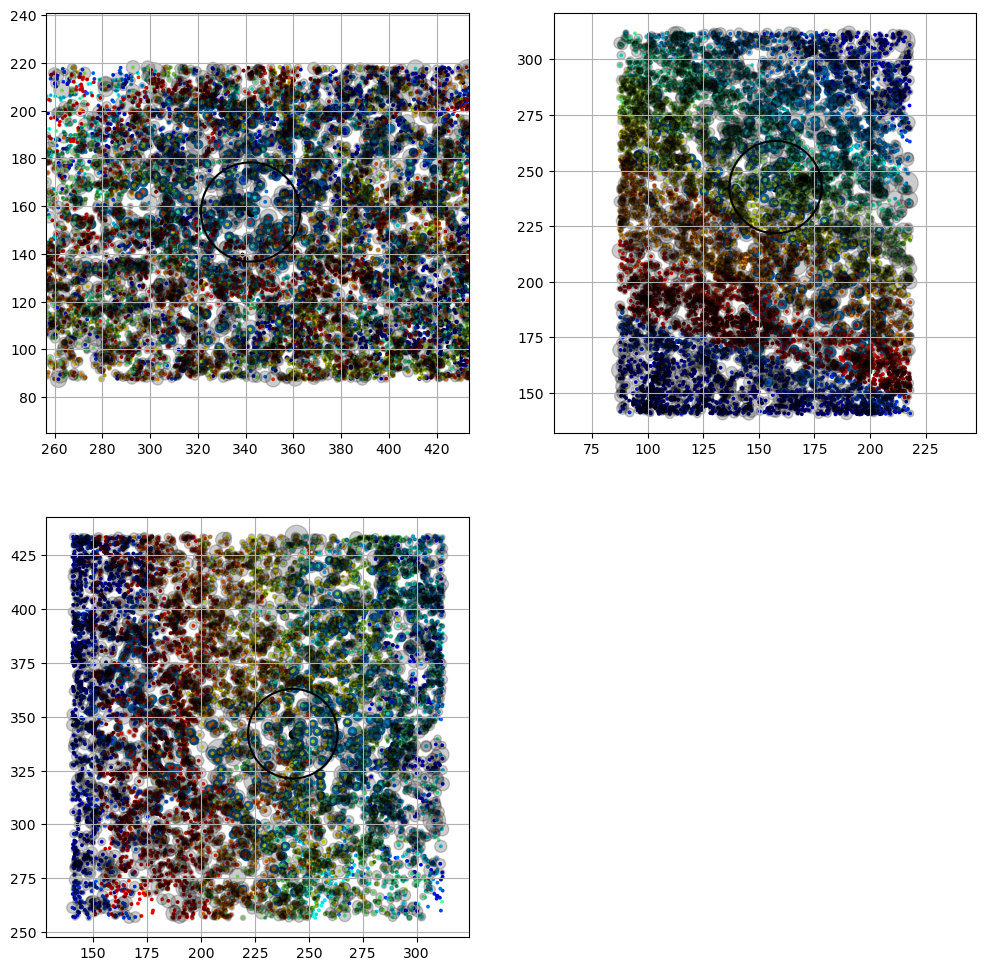

In [21]:
print(Ids_voro_dict[id_void][:Ncells_ref])
fig = plt.figure(figsize=(12,12))
ax = dict()
Rfac = 1.
for xx in range(3):
    ax[xx] = plt.subplot2grid((2,2), (int(xx/2),xx%2), rowspan=1, colspan=1)
    ax[xx].scatter(XYZ_ref[xx],XYZ_ref[(xx+1)%3],c='k')#,s=300)
    ax[xx].scatter(VoroXYZ[id_voro,xx]-offset[xx],VoroXYZ[id_voro,(xx+1)%3]-offset[(xx+1)%3],c='r')
    ax[xx].scatter(VoroXYZ[Ids_voro_dict[id_void][:Ncells_ref],xx]-offset[xx],
                   VoroXYZ[Ids_voro_dict[id_void][:Ncells_ref],(xx+1)%3]-offset[(xx+1)%3])
    ax[xx].plot(XYZ_ref[xx]+Rvds[id_void]*np.cos(theta),XYZ_ref[(xx+1)%3]+Rvds[id_void]*np.sin(theta),c='k')
    ax[xx].axis('equal')
    #ax[xx].set_xlim(XYZ_ref[xx]-Rvds[id_void]*Rfac,XYZ_ref[xx]+Rvds[id_void]*Rfac)
    #ax[xx].set_ylim(XYZ_ref[(xx+1)%3]-Rvds[id_void]*Rfac,XYZ_ref[(xx+1)%3]+Rvds[id_void]*Rfac)

mask = (VoroXYZ[:,0]-offset[0] > ax[0].set_xlim()[0]) & (VoroXYZ[:,0]-offset[0] < ax[0].set_xlim()[1]) & \
       (VoroXYZ[:,1]-offset[1] > ax[1].set_xlim()[0]) & (VoroXYZ[:,1]-offset[1] < ax[1].set_xlim()[1]) & \
       (VoroXYZ[:,2]-offset[2] > ax[2].set_xlim()[0]) & (VoroXYZ[:,2]-offset[2] < ax[2].set_xlim()[1])
for xx in range(3):
    ax[xx].scatter(VoroXYZ[mask,xx]-offset[xx],VoroXYZ[mask,(xx+1)%3]-offset[(xx+1)%3],c=np.arange(np.sum(mask)),cmap='jet',s=3)
    ax[xx].scatter(VoroXYZ[mask,xx]-offset[xx],VoroXYZ[mask,(xx+1)%3]-offset[(xx+1)%3],s=VoroVol[mask]/20,alpha=0.2,c='k')
    ax[xx].grid()

[  61.96931069   36.53333673   47.37789879 ...  661.57575724 1982.80666515
  367.20571123]


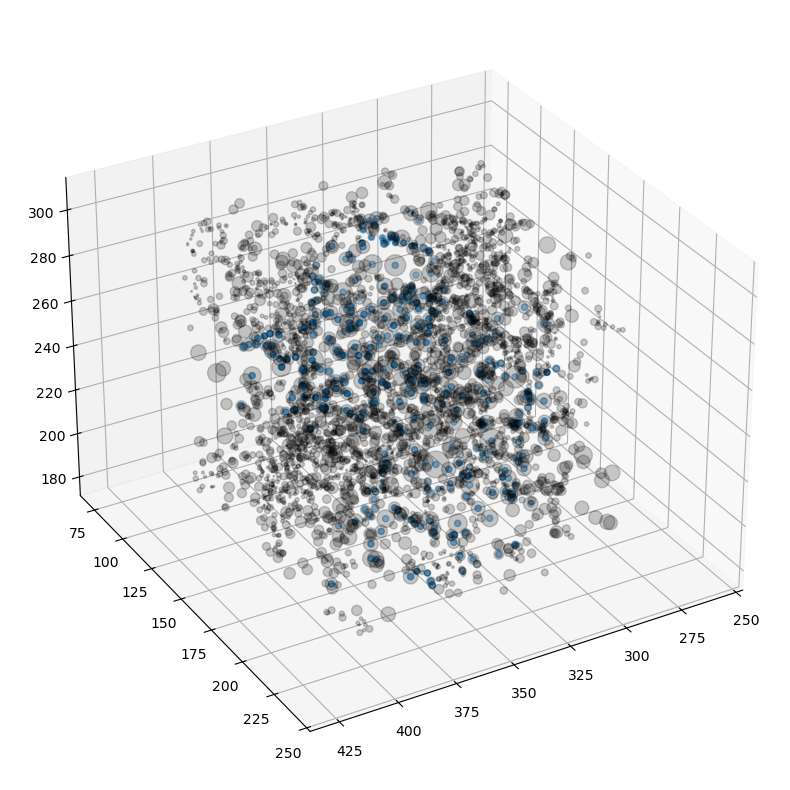

In [22]:
Rfac = 3

fig = plt.figure(figsize=(10,10))
ax = fig.add_subplot(projection='3d')
#ax.scatter(XYZ_ref[0],XYZ_ref[1],XYZ_ref[2],c='k',s=300)
mask = (VoroXYZ[:,0]-offset[0] > XYZ_ref[0]-Rvds[id_void]*Rfac) & (VoroXYZ[:,0]-offset[0] < XYZ_ref[0]+Rvds[id_void]*Rfac) & \
       (VoroXYZ[:,1]-offset[1] > XYZ_ref[1]-Rvds[id_void]*Rfac) & (VoroXYZ[:,1]-offset[1] < XYZ_ref[1]+Rvds[id_void]*Rfac) & \
       (VoroXYZ[:,2]-offset[2] > XYZ_ref[2]-Rvds[id_void]*Rfac) & (VoroXYZ[:,2]-offset[2] < XYZ_ref[2]+Rvds[id_void]*Rfac)
ax.scatter(VoroXYZ[mask,0]-offset[0],
           VoroXYZ[mask,1]-offset[1],
           VoroXYZ[mask,2]-offset[2],s=VoroVol[mask]/20,alpha=0.2,c='k')
print(VoroVol[mask])

mask = (VoroXYZ[Ids_voro_dict[id_void][:Ncells_ref],0]-offset[0] > XYZ_ref[0]-Rvds[id_void]*Rfac) & (VoroXYZ[Ids_voro_dict[id_void][:Ncells_ref],0]-offset[0] < XYZ_ref[0]+Rvds[id_void]*Rfac) & \
       (VoroXYZ[Ids_voro_dict[id_void][:Ncells_ref],1]-offset[1] > XYZ_ref[1]-Rvds[id_void]*Rfac) & (VoroXYZ[Ids_voro_dict[id_void][:Ncells_ref],1]-offset[1] < XYZ_ref[1]+Rvds[id_void]*Rfac) & \
       (VoroXYZ[Ids_voro_dict[id_void][:Ncells_ref],2]-offset[2] > XYZ_ref[2]-Rvds[id_void]*Rfac) & (VoroXYZ[Ids_voro_dict[id_void][:Ncells_ref],2]-offset[2] < XYZ_ref[2]+Rvds[id_void]*Rfac)
ax.scatter(VoroXYZ[Ids_voro_dict[id_void][:Ncells_ref],0][mask]-offset[0],
           VoroXYZ[Ids_voro_dict[id_void][:Ncells_ref],1][mask]-offset[1],
           VoroXYZ[Ids_voro_dict[id_void][:Ncells_ref],2][mask]-offset[2])
ax.scatter(VoroXYZ[id_voro,0]-offset[0],VoroXYZ[id_voro,1]-offset[1],VoroXYZ[id_voro,2]-offset[2],c='r',s=1)
ax.axis('equal')
#ax.set_xlim(XYZ_ref[0]-Rvds[id_void]*Rfac,XYZ_ref[0]+Rvds[id_void]*Rfac)
#ax.set_ylim(XYZ_ref[1]-Rvds[id_void]*Rfac,XYZ_ref[1]+Rvds[id_void]*Rfac)
#ax.set_zlim(XYZ_ref[2]-Rvds[id_void]*Rfac,XYZ_ref[2]+Rvds[id_void]*Rfac)
#ax.view_init(-140, 60)
#ax.view_init(30,120)
ax.view_init(None,60)



In [23]:
center_in_void_core(
    id_loop, ids_voro_center, IDS_voids, XYZ_voids, VolVoids, Ncells, 
    max_dist_vds, R_max, Ids_voro_dict, ind_vox, ngrid, voxel_side)

-1

In [24]:
ids_in_void = center_in_void_loop(
    IDS_voids, id_sorted, XYZ_voids, VolVoids, Ncells, ids_voro_center, max_dist_vds, Ids_voro_dict, ind_vox, ngrid, voxel_side)
print(ids_in_void)

[ -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1 160  -1  -1  -1  -1  -1
  -1  -1  -1  -1  -1  87  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1
  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1
  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1 113
  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1
  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1 205  -1  -1  -1  -1  -1
  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1
  -1  -1  -1  -1  -1  -1  -1  -1 112  -1  -1  -1  -1  -1  -1  -1  -1  -1
  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1
  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  87
  -1  -1  -1  94  87  -1  -1  -1  -1  -1  -1  -1  -1  -1  87  -1  -1  -1
  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1]


In [25]:
mask_max = Rvds >= np.max(Rvds) - 1e-3
imax = np.argmax(Rvds)
print(ids_closest[mask_max])

ids_max = np.arange(mask_max.shape[0])[mask_max]
print(ids_max,imax)
print(Rvds[mask_max])
id_void = ids_max[0]
print('id_void:',id_void)
for id_trs in ids_max:
    bool_base = ((Rvds[id_trs] > Rvds[id_void]) & (id_trs != id_void))
    bool_extra = (
        (Rvds[id_trs] == Rvds[id_void]) & \
        (ids_voro_center[id_trs] == ids_voro_center[id_void]) & \
        (id_trs > id_void))
    bool_tot = bool_base | bool_extra
    print('id_trs:',id_trs,', R==Rmax:',Rvds[id_trs] == Rvds[id_void],
          ', id_trs > id_void:',(id_trs > id_void),
          ', bool_base:',bool_base,', bool_extra:',bool_extra,', bool_tot:',bool_tot) 



[130756 130756 130756 130756]
[ 23  87 184 194] 87
[20.76518836 20.76518836 20.76518836 20.76518836]
id_void: 23
id_trs: 23 , R==Rmax: True , id_trs > id_void: False , bool_base: False , bool_extra: False , bool_tot: False
id_trs: 87 , R==Rmax: False , id_trs > id_void: True , bool_base: True , bool_extra: False , bool_tot: True
id_trs: 184 , R==Rmax: False , id_trs > id_void: True , bool_base: True , bool_extra: False , bool_tot: True
id_trs: 194 , R==Rmax: True , id_trs > id_void: True , bool_base: False , bool_extra: True , bool_tot: True


In [26]:
#center_in_void(
#    XYZ_voids, VolVoids, Ncells, VoroXYZ, VoroVol, ID_voro_dict, Lbox=-1.,lightcone=True,
#    ngrid_voro=-1,ngrid_voids=-1,max_iterations=3,nthreads=-1,verbose=True,Omega_rad=-1.,id_selected=None)

In [27]:
#threshold = [0.3]
#void_selected, ID_voro_dict, Xcm, Vol_interp, Ncells_in_void, ell_eigenvalues, ell_eigenvectors = voronoi_threshold(
#    threshold,ID_core,neighbor_ptr,neighbor_ids,VoroXYZ,VoroVol,tracer_dens,Lbox=-1,nthreads=-1,verbose=True,max_num_part=max_num_part)
       
ith=0
xyz_vds, vol_vds, Ncells, xyz_voro, vol_voro, IDs_in_voids = Xcm[:,ith,:], Vol_interp[:,ith], Ncells_in_void[:,ith], VoroXYZ, VoroVol, ID_voro_dict
Lbox=-1.
lightcone=True
ngrid_voro=-1
ngrid_voids=-1
max_iterations=3
nthreads=-1
verbose=True
Omega_rad=-1.
id_selected=None

In [28]:
from numba import get_num_threads

verboseprint = print if verbose else lambda *a, **k: None

verboseprint("\ncenter_in_void started.",flush=True)

if id_selected is None:
    verboseprint("\nid_selected not passed, set condition Ncells > 1.",flush=True)
    id_selected = np.arange(Ncells.shape[0])[Ncells > 1.]

try:
    nthreads_tot = int(os.environ["OMP_NUM_THREADS"])
except:
    nthreads_tot = get_num_threads()

if (nthreads <= 0) | (nthreads > nthreads_tot):
    nthreads = nthreads_tot

#set_num_threads(min(nthreads,id_selected.shape[0]))

verboseprint('\n    nthreads set to',nthreads,flush=True)

if (not lightcone) & (Lbox > 0):
    R_max = compute_max_dist2_pbc(Ncells,xyz_vds,xyz_voro,id_selected,IDs_in_voids,Lbox)**0.5
else:
    R_max = compute_max_dist2(Ncells,xyz_vds,xyz_voro,id_selected,IDs_in_voids)**0.5
#print('R_max:',R_max,flush=True)
#print('xyz_vds:',xyz_vds[id_selected],flush=True)
#print('IDs_in_voids:',IDs_in_voids,flush=True)
verboseprint('\n    R_max computed. Max val =',(np.max(R_max)),flush=True)


if (Lbox < 0):
    if not lightcone:
        print("    WARNING: Lbox not passed and lightcone = False. We suggest either to pass Lbox or set lightcone = True.",
                "\n    Lightcone authomatically set to True.",flush=True)
        verboseprint("    Computing Lbox using xyz_voro as reference:",flush=True)
        lightcone = True
    else:
        verboseprint("\n    Lbox not passed, using xyz_voro as reference:",flush=True)
if lightcone:
    if Lbox > 0:
        verboseprint("\n    Lbox passed but lightcone = True: Lbox will be ignored.",flush=True)

    offset = np.min(xyz_voro,axis=0)
    max_values = np.max(xyz_voro,axis=0)
    Lbox = np.max(max_values - offset)

    offset -= Lbox*1e-4
    max_values += Lbox*1e-4
    Lbox = np.max(max_values - offset)

    
    verboseprint("    min(xyz_voro) =",*offset,flush=True)
    verboseprint("    max(xyz_voro) =",*max_values,flush=True)
    verboseprint("    Lbox =",Lbox,flush=True)
else:
    offset = 0.
    if Lbox < 0:
        max_values = np.max(xyz_voro,axis=0)
        Lbox = np.max(max_values - offset)
        print("    WARNING: Lbox not passed and lightcone = False. We suggest either to pass Lbox or set lightcone = True.",flush=True)



if ngrid_voro < 0:
    #ngrid = max(int(round(5 * Lbox / np.sqrt(np.max(R2_max)))),3)
    ngrid_voro = max(int(round(Lbox / np.max(vol_voro)**(1./3.) )),4)

    verboseprint("\n    ngrid_voro not passed. Set to optimal value:",ngrid_voro,flush=True)

if ngrid_voids < 0:
    ngrid_voids = max(int(round(Lbox / np.max(R_max) )),4)

    verboseprint("\n    ngrid_voids not passed. Set to optimal value:",ngrid_voids,flush=True)




voxel_side_voro = Lbox / ngrid_voro

verboseprint('\n    order_coord_tracers_in_voxels_ids_rev_copy started',flush=True)
t0 = time.time()

xyz_trs_out, ids_reverse_voro, ind_vox_voro = order_coord_tracers_in_voxels_ids_rev_copy(xyz_voro - offset, ngrid_voro, Lbox)

dt = time.time() - t0
verboseprint("    done,",StrHminSec(dt),flush=True)


verboseprint('\n    nearest_cell_loop started',flush=True)
t0 = time.time()
ids_closest_voro = nearest_cell_loop(
    id_selected, xyz_vds-offset, xyz_trs_out, ids_reverse_voro, ind_vox_voro, ngrid_voro, voxel_side_voro, max_iterations)

#ids_closest = nearest_cell_loop(
#    id_selected, xyz_vds-offset, xyz_trs_out, ids_reverse, ind_vox, ngrid, voxel_side, max_iterations)

dt = time.time() - t0
verboseprint("    done,",StrHminSec(dt),flush=True)


verboseprint('\n    order_ids_tracers_selected_in_voxels started',flush=True)
#IDs_vds_ordered, voxel_ptr = order_ids_tracers_in_voxels(xyz_vds, ngrid, Lbox)

IDs_vds_ordered, id_sorted, ind_vox_voids = order_ids_tracers_selected_in_voxels(xyz_vds - offset, id_selected, ngrid_voids , Lbox)

dt = time.time() - t0
verboseprint("    done,",StrHminSec(dt),flush=True)

verboseprint("\n    computation started (periodic-boundaries condition "+['on','off'][int(lightcone)]+")",flush=True)
voxel_side_voids = Lbox / ngrid_voids
if lightcone:
    t0 = time.time()
    ids_in_void = center_in_void_loop(
        IDs_vds_ordered, id_sorted, xyz_vds - offset, vol_vds, Ncells, 
        ids_closest_voro, R_max, IDs_in_voids, ind_vox_voids, ngrid_voids, voxel_side_voids)
    dt = time.time() - t0
else:
    t0 = time.time()
    ids_in_void = center_in_void_loop(
        IDs_vds_ordered, id_sorted, xyz_vds - offset, vol_vds, Ncells, 
        ids_closest_voro, R_max, IDs_in_voids, ind_vox_voids, ngrid_voids, voxel_side_voids)
    dt = time.time() - t0
verboseprint("    done,",StrHminSec(dt),'\n',flush=True)

print(ids_in_void)



center_in_void started.

id_selected not passed, set condition Ncells > 1.

    nthreads set to 32

    R_max computed. Max val = 99.34885906394673

    Lbox not passed, using xyz_voro as reference:
    min(xyz_voro) = -404.89752 -433.31003 -84.366234
    max(xyz_voro) = 379.357 432.73975 402.80176
    Lbox = 866.0498

    ngrid_voro not passed. Set to optimal value: 44

    ngrid_voids not passed. Set to optimal value: 9

    order_coord_tracers_in_voxels_ids_rev_copy started
    done, 0 h 0 min 0.10570859909057617 sec.

    nearest_cell_loop started
    done, 0 h 0 min 0.08801817893981934 sec.

    order_ids_tracers_selected_in_voxels started
    done, 0 h 0 min 0.28949594497680664 sec.

    computation started (periodic-boundaries condition off)
    done, 0 h 0 min 0.7960450649261475 sec. 

[ -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1 160  -1  -1  -1  -1  -1
  -1  -1  -1  -1  -1  87  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1
  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1

In [29]:
ids_in_void, ids_closest_voro = center_in_void(
    xyz_vds, vol_vds, Ncells, xyz_voro, vol_voro, IDs_in_voids, Lbox=-1.,lightcone=True,
    ngrid_voro=-1,ngrid_voids=-1,max_iterations=3,nthreads=-1,verbose=True,id_selected=None)


center_in_void started.

id_selected not passed, set condition Ncells > 1.

    nthreads set to 32

    R_max computed. Max val = 99.34885906394673

    Lbox not passed, using xyz_voro as reference:
    min(xyz_voro) = -404.89752 -433.31003 -84.366234
    max(xyz_voro) = 379.357 432.73975 402.80176
    Lbox = 866.0498

    ngrid_voro not passed. Set to optimal value: 44

    ngrid_voids not passed. Set to optimal value: 9

    order_ids_tracers_selected_in_voxels started
    done, 0 h 0 min 0.09591269493103027 sec.

    order_ids_tracers_selected_in_voxels started
    done, 0 h 0 min 0.29700422286987305 sec.

    computation started (periodic-boundaries condition off)
    done, 0 h 0 min 0.4969789981842041 sec. 



In [30]:
print(ids_in_void)

[ -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1 160  -1  -1  -1  -1  -1
  -1  -1  -1  -1  -1  87  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1
  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1
  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1 113
  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1
  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1 205  -1  -1  -1  -1  -1
  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1
  -1  -1  -1  -1  -1  -1  -1  -1 112  -1  -1  -1  -1  -1  -1  -1  -1  -1
  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1
  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  87
  -1  -1  -1  94  87  -1  -1  -1  -1  -1  -1  -1  -1  -1  87  -1  -1  -1
  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1]


In [31]:
id_selected = np.arange(Ncells.shape[0])[Ncells > 1.]

order_id_selected = (np.argsort(Vol_interp[ids_selected[ith],ith])[::-1]).astype(dtype=np.int_, order='C')


mask_overlapping = ids_in_void > -1
ids_overlapping = id_selected[mask_overlapping]
ids_larger_void = ids_in_void[mask_overlapping]
print('ids_overlapping:',ids_overlapping)
print('ids_larger_void:',ids_larger_void)
print('vol overlapping:',vol_vds[ids_overlapping])
print('vol larger void:',vol_vds[ids_overlapping])

ids_overlapping: [ 12  23  71 102 134 179 183 184 194]
ids_larger_void: [160  87 113 205 112  87  94  87  87]
vol overlapping: [  8497.54459189 658072.06068765  37296.10873966   1660.12226924
   7689.24380005   1969.24522646  25353.3056824  658072.06068765
 658072.06068765]
vol larger void: [  8497.54459189 658072.06068765  37296.10873966   1660.12226924
   7689.24380005   1969.24522646  25353.3056824  658072.06068765
 658072.06068765]


In [32]:
for ii in range(ids_overlapping.shape[0]):
    print('id:',ids_overlapping[ii],
          'larger:',ids_larger_void[ii],
          'vol id:',vol_vds[ids_overlapping[ii]],
          'vol larger:',vol_vds[ids_larger_void[ii]],
          'is larger:',vol_vds[ids_larger_void[ii]]>vol_vds[ids_overlapping[ii]],
          'is equal:',vol_vds[ids_larger_void[ii]]==vol_vds[ids_overlapping[ii]])

id: 12 larger: 160 vol id: 8497.54459189337 vol larger: 9582.158086323923 is larger: True is equal: False
id: 23 larger: 87 vol id: 658072.0606876512 vol larger: 658072.0606876514 is larger: True is equal: False
id: 71 larger: 113 vol id: 37296.108739661184 vol larger: 62461.222800988915 is larger: True is equal: False
id: 102 larger: 205 vol id: 1660.122269238307 vol larger: 12365.208035075686 is larger: True is equal: False
id: 134 larger: 112 vol id: 7689.243800051668 vol larger: 26753.345485656926 is larger: True is equal: False
id: 179 larger: 87 vol id: 1969.2452264573108 vol larger: 658072.0606876514 is larger: True is equal: False
id: 183 larger: 94 vol id: 25353.305682398888 vol larger: 83224.07901674675 is larger: True is equal: False
id: 184 larger: 87 vol id: 658072.0606876514 vol larger: 658072.0606876514 is larger: False is equal: True
id: 194 larger: 87 vol id: 658072.0606876513 vol larger: 658072.0606876514 is larger: True is equal: False


In [33]:
for ii in ids_overlapping:
    print(ii, ii in ids_larger_void)

12 False
23 False
71 False
102 False
134 False
179 False
183 False
184 False
194 False


In [34]:
ids_in_void, ids_closest_voro = center_in_void(
    xyz_vds, vol_vds, Ncells, xyz_voro, vol_voro, IDs_in_voids, Lbox=-1.,lightcone=True,
    ngrid_voro=-1,ngrid_voids=-1,max_iterations=3,nthreads=-1,verbose=True,id_selected=ids_selected[ith]) 


center_in_void started.

    nthreads set to 32

    R_max computed. Max val = 44.66014755275007

    Lbox not passed, using xyz_voro as reference:
    min(xyz_voro) = -404.89752 -433.31003 -84.366234
    max(xyz_voro) = 379.357 432.73975 402.80176
    Lbox = 866.0498

    ngrid_voro not passed. Set to optimal value: 44

    ngrid_voids not passed. Set to optimal value: 19

    order_ids_tracers_selected_in_voxels started
    done, 0 h 0 min 0.18611502647399902 sec.

    order_ids_tracers_selected_in_voxels started
    done, 0 h 0 min 0.3873484134674072 sec.

    computation started (periodic-boundaries condition off)
    done, 0 h 0 min 0.8985562324523926 sec. 



In [35]:
print(ids_in_void,ids_in_void.shape)

[ -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1
  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1
  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1
  -1  -1  -1  -1  -1 169  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1
  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1
  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1
  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1
  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1] (136,)


In [36]:
mask_overlapping = ids_in_void > -1
ids_overlapping = np.arange(ids_selected[ith].shape[0])[mask_overlapping]
ids_overlapping = ids_selected[ith][mask_overlapping]
ids_larger_void = ids_in_void[mask_overlapping]

for ii in range(ids_overlapping.shape[0]):
    print('id:',ids_overlapping[ii],
          'larger:',ids_larger_void[ii],
          'vol id:',vol_vds[ids_overlapping[ii]],
          'vol larger:',vol_vds[ids_larger_void[ii]],
          'is larger:',vol_vds[ids_larger_void[ii]]>vol_vds[ids_overlapping[ii]],
          'is equal:',vol_vds[ids_larger_void[ii]]==vol_vds[ids_overlapping[ii]])

mask_overlapping = ids_in_void > -1
overlapping_pairs = np.empty((np.sum(mask_overlapping),2),dtype=np.int64)
overlapping_pairs[:,0] = ids_selected[ith][mask_overlapping]
overlapping_pairs[:,1] = ids_in_void[mask_overlapping]

print(overlapping_pairs)

id: 103 larger: 169 vol id: 11813.364693973355 vol larger: 12966.445282426404 is larger: True is equal: False
[[103 169]]


In [37]:
def select_overlaps_center_in_void(overlapping_pairs,VolArr):
    Ntot = overlapping_pairs.shape[0]
    id_sort = (np.argsort(VolArr[overlapping_pairs[:,0]])[::-1]).astype(dtype=np.int64, order='C')
    overlapping_pairs_out = np.copy(overlapping_pairs[id_sort,:])
    ind = 0
    while ind < Ntot:
        if overlapping_pairs_out[ind,0] in overlapping_pairs_out[:Ntot,1]:
            overlapping_pairs_out[ii:-1,:] = overlapping_pairs_out[ii+1:,:]
            Ntot -= 1
        ind += 1
        
    return overlapping_pairs_out[:Ntot,:]

print(select_overlaps_center_in_void(overlapping_pairs,vol_vds))
overlapping_pairs_out = select_overlaps_center_in_void(overlapping_pairs,vol_vds)

[[103 169]]


In [38]:
def nonoverlapping_center_in_void(id_selected,ids_overlapping_out):
    mask_ovlp = np.zeros(Xcm.shape[0],dtype=np.bool_)
    mask_ovlp[ids_selected] = True
    mask_ovlp[ids_overlapping_out] = False

    ids_out = np.arange(Xcm.shape[0])[mask_ovlp]


In [39]:
ids_in_void_test, ids_closest_voro = center_in_void(
    xyz_vds, vol_vds, Ncells, xyz_voro, vol_voro, IDs_in_voids, Lbox=-1.,lightcone=True,
    ngrid_voro=-1,ngrid_voids=-1,max_iterations=3,nthreads=-1,verbose=True,id_selected=ids_selected[ith]) 


ids_closest_voro_test = closest_voro(
xyz_vds, Ncells, xyz_voro, vol_voro, IDs_in_voids, Lbox=-1.,lightcone=True,
ngrid_voro=-1,max_iterations=3,nthreads=-1,verbose=True,id_selected=ids_selected[ith]) 

ids_in_void_test = center_in_void_given_voro(
    xyz_vds, vol_vds, Ncells, xyz_voro, IDs_in_voids, ids_closest_voro_test, Lbox=-1.,lightcone=True,
    ngrid_voids=-1,nthreads=-1,verbose=True,id_selected=ids_selected[ith]) 

print('ids_closest_voro_test:',np.all(ids_closest_voro_test == ids_closest_voro))
print('ids_in_void_test:',np.all(ids_in_void_test == ids_in_void_test))


center_in_void started.

    nthreads set to 32

    R_max computed. Max val = 44.66014755275007

    Lbox not passed, using xyz_voro as reference:
    min(xyz_voro) = -404.89752 -433.31003 -84.366234
    max(xyz_voro) = 379.357 432.73975 402.80176
    Lbox = 866.0498

    ngrid_voro not passed. Set to optimal value: 44

    ngrid_voids not passed. Set to optimal value: 19

    order_ids_tracers_selected_in_voxels started
    done, 0 h 0 min 0.08288931846618652 sec.

    order_ids_tracers_selected_in_voxels started
    done, 0 h 0 min 0.3826022148132324 sec.

    computation started (periodic-boundaries condition off)
    done, 0 h 0 min 0.5975122451782227 sec. 


center_in_void started.

    nthreads set to 32

    R_max computed. Max val = 44.66014755275007

    Lbox not passed, using xyz_voro as reference:
    min(xyz_voro) = -404.89752 -433.31003 -84.366234
    max(xyz_voro) = 379.357 432.73975 402.80176
    Lbox = 866.0498

    ngrid_voro not passed. Set to optimal value: 44

   